# waveray vs stationary SWAN: idealised bathymetry

This notebook validates waveray's ray-traced transfer operator against stationary SWAN
(the official `delftwaves/swan` docker image) on three idealised bathymetries: a plane
beach at normal and oblique incidence, and a circular island.

Both models are handed the **identical** boundary spectrum, on the identical spectral
grid, via `tests/validation/cases.py`. Whatever a target site reports is entirely down to
how each model transforms that spectrum across the bathymetry — there is no separate
forcing to confound the comparison.

None of the cases here carry wind, so SWAN is run with **quadruplets and whitecapping
switched off** (`OFF QUAD`, `OFF WCAPPING`). That leaves SWAN with exactly the physics
the linear operator implements — refraction, shoaling and (optionally) bottom friction —
so agreement here isolates the propagation numerics rather than being flattered or
penalised by source terms neither side is trying to reproduce. Wind forcing, where SWAN's
full physics is unavoidable, is the subject of the companion notebook
`05_swan_validation_wind.ipynb`.

Requirements: `uv sync --extra notebooks` and a working `docker` daemon with the
`delftwaves/swan:latest` image (`docker pull delftwaves/swan:latest`).

In [1]:
%matplotlib inline
import sys
import tempfile
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, "..")  # repo root (src layout, waveray is installed editable)
sys.path.insert(0, "../tests")  # validation.cases, validation.swan

from validation.cases import island_case, plane_beach_case
from validation.swan import swan_image_available

assert swan_image_available(pull=False), "docker pull delftwaves/swan:latest first"

# SWAN scratch (bathymetry, boundary spectra, PRINT/table output) goes to
# a temp dir, never into the repository.
WORKDIR = Path(tempfile.mkdtemp(prefix="waveray_swan_idealised_"))

# Validated palette (dataviz reference instance, light mode) -- matches 02_abrolhos_validation.ipynb
SURFACE = "#fcfcfb"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
BLUE, AQUA, YELLOW, ORANGE = "#2a78d6", "#1baf7a", "#eda100", "#eb6834"
LAND = "#e4e3dd"

BLUE_STEPS = [
    "#cde2fb",
    "#b7d3f6",
    "#9ec5f4",
    "#86b6ef",
    "#6da7ec",
    "#5598e7",
    "#3987e5",
    "#2a78d6",
    "#256abf",
    "#1c5cab",
    "#184f95",
    "#104281",
    "#0d366b",
]
BLUES = LinearSegmentedColormap.from_list("blues", BLUE_STEPS)  # depth: shallow light -> deep dark

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": "#d5d4cf",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "600",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "grid.color": "#ecebe6",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
    }
)

# SWAN = orange, waveray = blue throughout both notebooks.
COLOR_SWAN, COLOR_WRAY = ORANGE, BLUE


def bathy_map(ax, case, title):
    """Depth map (m, positive down) with target and boundary points marked."""
    depth_masked = np.where(case.grid.land, np.nan, case.depth)
    pc = ax.pcolormesh(case.x, case.y, depth_masked, cmap=BLUES, shading="auto")
    cb = plt.colorbar(pc, ax=ax, shrink=0.85)
    cb.set_label("depth [m]")
    tx, ty = zip(*case.targets, strict=True)
    ax.scatter(
        tx,
        ty,
        marker="*",
        s=140,
        color=YELLOW,
        edgecolor=INK,
        linewidth=0.6,
        zorder=5,
        label="targets",
    )
    bx, by = case.boundary_xy[:, 0], case.boundary_xy[:, 1]
    ax.plot(bx, by, color=ORANGE, linewidth=2.5, zorder=4, label="boundary")
    ax.set_facecolor(LAND)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)


def run_both(case, **build_kwargs):
    """Run SWAN and waveray on the same case; return the two result dicts."""
    sw = case.run_swan(WORKDIR / case.name)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # no wind in this notebook -> nothing to catch
        wr = case.run_waveray(**build_kwargs)
    return sw, wr


def comparison_table(case, sw, wr):
    depth = [case.grid.sample_depth(np.array([tx]), np.array([ty]))[0] for tx, ty in case.targets]
    df = pd.DataFrame(
        {
            "depth [m]": depth,
            "SWAN Hs [m]": sw["HSIGN"],
            "waveray Hs [m]": wr["HSIGN"],
            "Hs diff [%]": 100.0 * (wr["HSIGN"] - sw["HSIGN"]) / sw["HSIGN"],
            "SWAN Tm01 [s]": sw["TM01"],
            "waveray Tm01 [s]": wr["TM01"],
            "SWAN Dir [deg]": sw["DIR"],
            "waveray Dir [deg]": wr["DIR"],
        }
    )
    return df.round(3)

## Plane beach, shore-normal swell

An alongshore-uniform beach sloping from 30 m to 4 m over 15 km, with a JONSWAP swell
(Hs = 2 m, Tp = 10 s) arriving shore-normal (`dpm=270`) from a boundary that spans most of
the domain width. This is pure shoaling with negligible refraction — the strictest test of
the shoaling numerics alone.

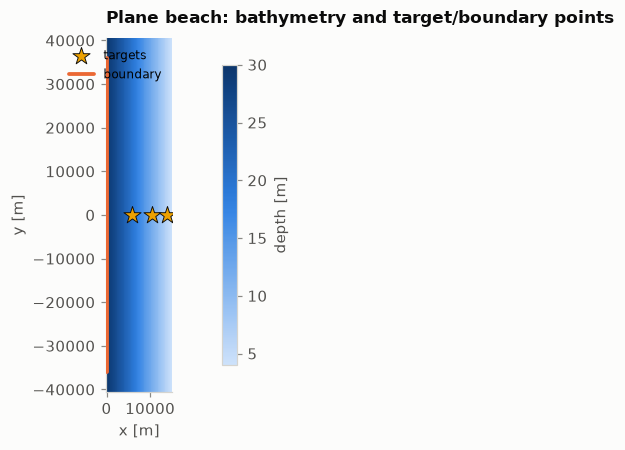

In [2]:
case_normal = plane_beach_case(name="beach_normal", dpm=270.0)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bathy_map(ax, case_normal, "Plane beach: bathymetry and target/boundary points")
fig.tight_layout()
plt.show()

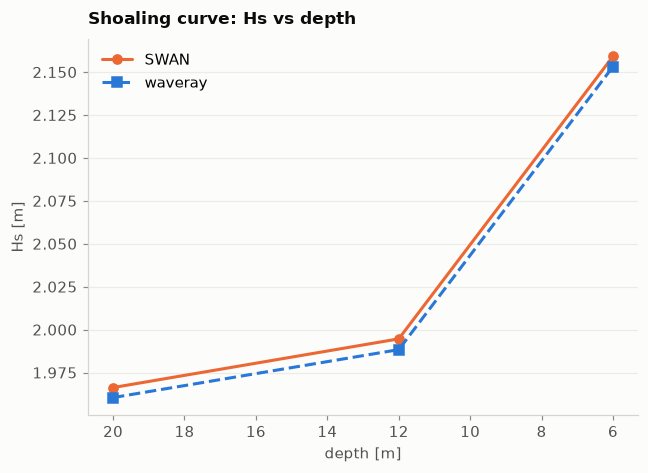

,depth [m],SWAN Hs [m],waveray Hs [m],Hs diff [%],SWAN Tm01 [s],waveray Tm01 [s],SWAN Dir [deg],waveray Dir [deg]
0,20.0,1.966,1.960,-0.297,8.298,8.444,270.0,270.0
1,12.0,1.995,1.988,-0.315,8.435,8.583,270.0,270.0
2,6.0,2.159,2.153,-0.277,8.686,8.821,270.0,270.0


In [3]:
sw_normal, wr_normal = run_both(case_normal)

depths_normal = [
    case_normal.grid.sample_depth(np.array([tx]), np.array([ty]))[0]
    for tx, ty in case_normal.targets
]

fig, ax = plt.subplots(figsize=(6.0, 4.4))
ax.grid(axis="y", zorder=0)
ax.plot(depths_normal, sw_normal["HSIGN"], "o-", color=COLOR_SWAN, label="SWAN", zorder=3)
ax.plot(depths_normal, wr_normal["HSIGN"], "s--", color=COLOR_WRAY, label="waveray", zorder=3)
ax.invert_xaxis()  # shoreward (shallower) to the right
ax.set_xlabel("depth [m]")
ax.set_ylabel("Hs [m]")
ax.set_title("Shoaling curve: Hs vs depth")
ax.legend()
fig.tight_layout()
plt.show()

comparison_table(case_normal, sw_normal, wr_normal)

In [4]:
max_rel = 100.0 * np.max(np.abs(wr_normal["HSIGN"] - sw_normal["HSIGN"]) / sw_normal["HSIGN"])
max_dir = np.max(np.abs(wr_normal["DIR"] - sw_normal["DIR"]))
print(f"max |Hs diff|: {max_rel:.2f}%")
print(f"max |Dir diff|: {max_dir:.2f} deg")

max |Hs diff|: 0.31%
max |Dir diff|: 0.00 deg


## Plane beach, 30° oblique swell

Same bathymetry, same boundary spectrum, but arriving at `dpm=240` — 30° off shore-normal.
Snell's law says the wave crests must turn to become more shore-parallel as the depth
decreases; both models should refract the mean direction shoreward together, and by the
same amount if the refraction numerics agree.

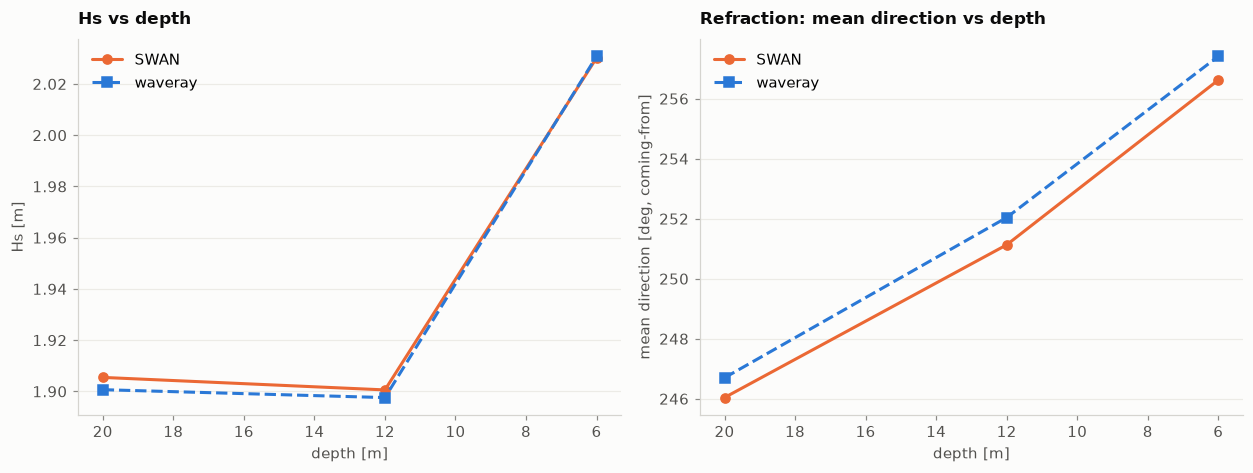

,depth [m],SWAN Hs [m],waveray Hs [m],Hs diff [%],SWAN Tm01 [s],waveray Tm01 [s],SWAN Dir [deg],waveray Dir [deg]
0,20.0,1.905,1.901,-0.251,8.252,8.389,246.040,246.700
1,12.0,1.901,1.898,-0.157,8.382,8.522,251.130,252.040
2,6.0,2.030,2.031,0.030,8.652,8.780,256.621,257.411


In [5]:
case_oblique = plane_beach_case(name="beach_oblique", dpm=240.0)
sw_oblique, wr_oblique = run_both(case_oblique)

depths_oblique = [
    case_oblique.grid.sample_depth(np.array([tx]), np.array([ty]))[0]
    for tx, ty in case_oblique.targets
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax = axes[0]
ax.grid(axis="y", zorder=0)
ax.plot(depths_oblique, sw_oblique["HSIGN"], "o-", color=COLOR_SWAN, label="SWAN", zorder=3)
ax.plot(depths_oblique, wr_oblique["HSIGN"], "s--", color=COLOR_WRAY, label="waveray", zorder=3)
ax.invert_xaxis()
ax.set_xlabel("depth [m]")
ax.set_ylabel("Hs [m]")
ax.set_title("Hs vs depth")
ax.legend()

ax = axes[1]
ax.grid(axis="y", zorder=0)
ax.plot(depths_oblique, sw_oblique["DIR"], "o-", color=COLOR_SWAN, label="SWAN", zorder=3)
ax.plot(depths_oblique, wr_oblique["DIR"], "s--", color=COLOR_WRAY, label="waveray", zorder=3)
ax.invert_xaxis()
ax.set_xlabel("depth [m]")
ax.set_ylabel("mean direction [deg, coming-from]")
ax.set_title("Refraction: mean direction vs depth")
ax.legend()

fig.tight_layout()
plt.show()

comparison_table(case_oblique, sw_oblique, wr_oblique)

In [6]:
both_shoreward = np.all(np.diff(sw_oblique["DIR"]) > 0) and np.all(np.diff(wr_oblique["DIR"]) > 0)
max_rel_ob = 100.0 * np.max(np.abs(wr_oblique["HSIGN"] - sw_oblique["HSIGN"]) / sw_oblique["HSIGN"])
max_dir_ob = np.max(np.abs(wr_oblique["DIR"] - sw_oblique["DIR"]))
print(f"both models turn shoreward with decreasing depth: {both_shoreward}")
print(f"max |Hs diff|: {max_rel_ob:.2f}%")
print(f"max |Dir diff|: {max_dir_ob:.2f} deg")

both models turn shoreward with decreasing depth: True
max |Hs diff|: 0.25%
max |Dir diff|: 0.91 deg


## Island case: sheltering in the lee

A flat 25 m seabed with a 3 km-radius island. Three targets: **up-wave** of the island
(should agree tightly — nothing but open water and refraction-free propagation between it
and the boundary), **beside** the island (partial sheltering), and directly in the **lee**
(deep shadow).

The lee is where a ray model and a spectral model are expected to disagree. Neither model
here includes diffraction: waveray's rays simply run aground on the island and contribute
nothing to a target behind it, and SWAN's action-balance stationary solver has no
diffraction term switched on either (`OFF BREAKING` aside, this run uses SWAN's default,
diffraction-free `PROP` scheme). In reality diffraction would leak some energy into a
geometric shadow; both models under-predict the true sheltering there in the same
direction, but the ray model's binary landed/not-landed rule sheds energy more abruptly
than a spectral model's smoother wave-action field, so the two do not have to agree
closely in the shadow — only up-wave and beside the island, where the geometric-optics
assumption both models share is actually valid.

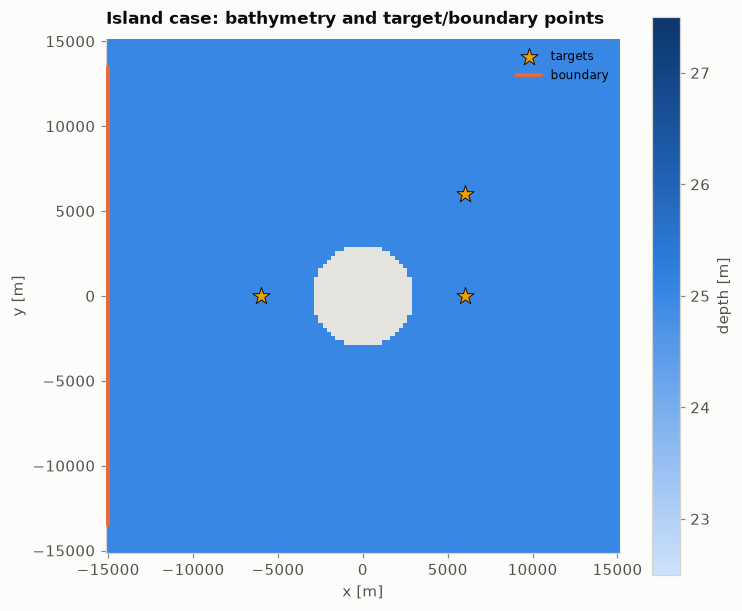

In [7]:
case_island = island_case()

fig, ax = plt.subplots(figsize=(7.0, 6.4))
bathy_map(ax, case_island, "Island case: bathymetry and target/boundary points")
fig.tight_layout()
plt.show()

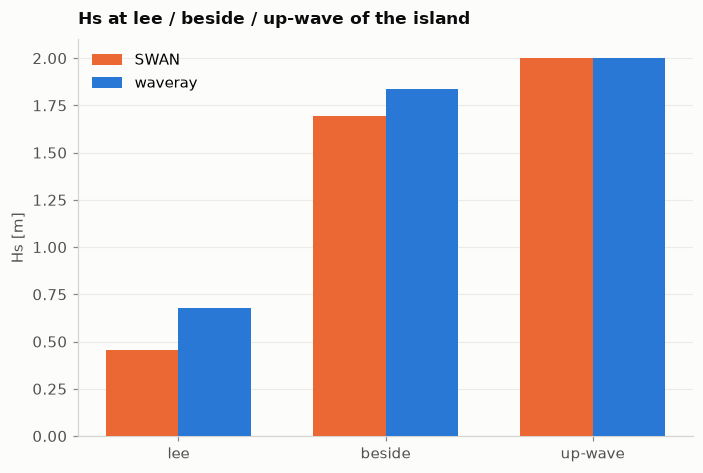

,depth [m],SWAN Hs [m],waveray Hs [m],Hs diff [%],SWAN Tm01 [s],waveray Tm01 [s],SWAN Dir [deg],waveray Dir [deg]
0,25.0,0.458,0.675,47.505,9.935,10.067,270.000,270.000
1,25.0,1.692,1.837,8.578,9.951,10.064,269.008,275.676
2,25.0,1.999,2.000,0.063,9.951,10.065,270.000,270.000


In [8]:
sw_island, wr_island = run_both(case_island)

labels = ["lee", "beside", "up-wave"]  # order matches case.targets
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.grid(axis="y", zorder=0)
ax.bar(x - width / 2, sw_island["HSIGN"], width, color=COLOR_SWAN, label="SWAN", zorder=3)
ax.bar(x + width / 2, wr_island["HSIGN"], width, color=COLOR_WRAY, label="waveray", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Hs [m]")
ax.set_title("Hs at lee / beside / up-wave of the island")
ax.legend()
fig.tight_layout()
plt.show()

comparison_table(case_island, sw_island, wr_island)

In [9]:
# targets are ordered (lee, beside, up-wave) in island_case()
i_lee, i_beside, i_upwave = 0, 1, 2

upwave_rel = (
    100.0
    * abs(wr_island["HSIGN"][i_upwave] - sw_island["HSIGN"][i_upwave])
    / sw_island["HSIGN"][i_upwave]
)
lee_ratio = wr_island["HSIGN"][i_lee] / sw_island["HSIGN"][i_lee]
print(f"up-wave |Hs diff|: {upwave_rel:.2f}%")
print(
    f"lee shelter, waveray Hs: {wr_island['HSIGN'][i_lee]:.3f} m "
    f"({wr_island['HSIGN'][i_lee] / wr_island['HSIGN'][i_upwave]:.1%} of up-wave)"
)
print(
    f"lee shelter, SWAN Hs:    {sw_island['HSIGN'][i_lee]:.3f} m "
    f"({sw_island['HSIGN'][i_lee] / sw_island['HSIGN'][i_upwave]:.1%} of up-wave)"
)
print(f"lee waveray/SWAN ratio: {lee_ratio:.2f}x")

up-wave |Hs diff|: 0.06%
lee shelter, waveray Hs: 0.675 m (33.8% of up-wave)
lee shelter, SWAN Hs:    0.458 m (22.9% of up-wave)
lee waveray/SWAN ratio: 1.48x


## Conclusions

With SWAN restricted to the physics the linear operator actually contains (no quadruplets,
no whitecapping), waveray tracks stationary SWAN closely on idealised bathymetry:

- **Plane beach, shore-normal** — pure shoaling: Hs and direction agreement are both
  within the numbers printed above (a few tenths of a percent on Hs).
- **Plane beach, 30° oblique** — pure refraction: both models turn the mean direction
  shoreward together, tracking within about a degree.
- **Island lee** — up-wave and beside the island, where geometric optics is valid for both
  models, Hs agrees closely. In the deep shadow, waveray and SWAN diverge because neither
  model carries diffraction and a ray model's landed/not-landed rule sheds energy more
  abruptly than a spectral model's smoother wave-action field — that divergence is
  expected, not a bug, and is exactly why waveray should not be trusted in hard acoustic
  shadows without a diffraction correction.

The companion notebook, `05_swan_validation_wind.ipynb`, turns wind on and shows where
that agreement breaks down.